# GoogLeNet (Inception v1) Implementation

### Problem Statement

GoogLeNet (Szegedy et al., 2014) is a 22-layer network that won the ImageNet challenge with roughly 12x fewer parameters than VGG-16. It introduces three core ideas:

1. **Inception module:** parallel branches at multiple filter sizes (1x1, 3x3, 5x5, pool) that capture features at different scales simultaneously.
2. **1x1 convolutions:** placed before the 3x3 and 5x5 convs to reduce channels first, which dramatically lowers the parameter count.
3. **Auxiliary classifiers:** intermediate output branches that help gradients flow through the deep network during training.

In this notebook, we implement the full architecture from scratch in PyTorch, train it on STL-10, and compare the results against a pretrained version fine-tuned on the same data.

## Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset, random_split
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Define Data Transforms
STL-10 images are 96x96. We apply random crop and horizontal flip on the training set, and only normalization on the test set.

In [ ]:
mean = [0.4467, 0.4398, 0.4066]
std = [0.2603, 0.2566, 0.2713]

train_transform = transforms.Compose([
    transforms.RandomCrop(96, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

## Load Dataset

In [ ]:
# Load STL-10 with no transforms — we'll attach them after splitting
raw_train = torchvision.datasets.STL10(root='./data', split='train', download=True)
raw_test = torchvision.datasets.STL10(root='./data', split='test', download=True)

# Combine and re-split 80/20 so train > test
combined = ConcatDataset([raw_train, raw_test])
n = len(combined)
train_size = int(0.65* n)
test_size = n - train_size
train_subset, test_subset = random_split(
    combined, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Wrapper to apply transforms after splitting
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]
        return self.transform(img), label

train_dataset = TransformedSubset(train_subset, train_transform)
test_dataset = TransformedSubset(test_subset, test_transform)

100%|██████████| 2.64G/2.64G [00:26<00:00, 97.9MB/s]


In [ ]:
print('Training samples:', len(train_dataset))
print('Test samples    :', len(test_dataset))

Training samples: 8450
Test samples    : 4550


## Class Names

In [ ]:
class_names = raw_train.classes
print(class_names)

['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


## Create DataLoaders

In [ ]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## Display Sample Images

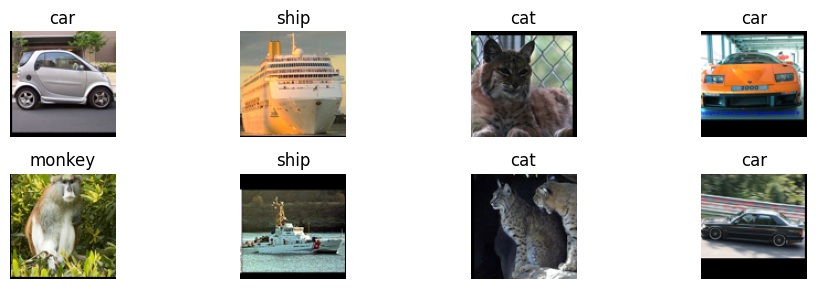

In [ ]:
def denormalize(img):
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    return (img * s + m).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]).permute(1, 2, 0))
    ax.set_title(class_names[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

## Check Input Shape

In [ ]:
print('Batch shape       :', images.shape)
print('Single image shape:', images[0].shape)

Batch shape       : torch.Size([64, 3, 96, 96])
Single image shape: torch.Size([3, 96, 96])


## BasicConv2d Helper
A reusable Conv -> BatchNorm -> ReLU block used throughout the network.

In [ ]:
class BasicConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)), inplace=True)

## Naive Inception Module
The naive version applies 1x1, 3x3, 5x5 convolutions and 3x3 max-pooling in parallel on the input, then concatenates the outputs along the channel dimension.

In [ ]:
class NaiveInception(nn.Module):
    def __init__(self, in_ch, out_1x1, out_3x3, out_5x5, out_pool):
        super().__init__()
        # Branch 1: 1x1 conv
        self.branch1 = BasicConv2d(in_ch, out_1x1, kernel_size=1)
        # Branch 2: 3x3 conv directly on input
        self.branch2 = BasicConv2d(in_ch, out_3x3, kernel_size=3, padding=1)
        # Branch 3: 5x5 conv directly on input
        self.branch3 = BasicConv2d(in_ch, out_5x5, kernel_size=5, padding=2)
        # Branch 4: 3x3 max-pool -> 1x1 conv
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_ch, out_pool, kernel_size=1)
        )

    def forward(self, x):
        # Concatenate the four branch outputs along the channel dimension
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)

## Inception Module with Dimension Reduction
The actual block used in GoogLeNet. It inserts 1x1 convolutions before the 3x3 and 5x5 convolutions to reduce channels first, drastically lowering the parameter count.

In [ ]:
class Inception(nn.Module):
    def __init__(self, in_ch, out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_pool):
        super().__init__()
        # Branch 1: 1x1 conv
        self.branch1 = BasicConv2d(in_ch, out_1x1, kernel_size=1)
        # Branch 2: 1x1 reduction -> 3x3 conv
        self.branch2 = nn.Sequential(
            BasicConv2d(in_ch, red_3x3, kernel_size=1),
            BasicConv2d(red_3x3, out_3x3, kernel_size=3, padding=1)
        )
        # Branch 3: 1x1 reduction -> 5x5 conv
        self.branch3 = nn.Sequential(
            BasicConv2d(in_ch, red_5x5, kernel_size=1),
            BasicConv2d(red_5x5, out_5x5, kernel_size=5, padding=2)
        )
        # Branch 4: 3x3 max-pool -> 1x1 conv
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_ch, out_pool, kernel_size=1)
        )

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)

## Compare Naive vs Reduced
Using the Inception-3a configuration from the paper to make the comparison concrete.

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

# Inception-3a config from the paper
naive = NaiveInception(in_ch=192, out_1x1=64, out_3x3=128, out_5x5=32, out_pool=32)
reduced = Inception(in_ch=192, out_1x1=64, red_3x3=96, out_3x3=128, red_5x5=16, out_5x5=32, out_pool=32)

comparison = pd.DataFrame({
    'Module': ['Naive Inception (Fig 2a)', 'Inception with 1x1 reduction (Fig 2b)'],
    'Parameters': [count_params(naive), count_params(reduced)],
})
display(comparison)


,Module,Parameters
0,Naive Inception (Fig 2a),393728
1,Inception with 1x1 reduction (Fig 2b),164064


### Observation
The reduced version uses ~2.4x fewer parameters than the naive version. The 1x1 convolutions placed before the 3x3 and 5x5 convs shrink the input channels first, so the larger convs operate on far fewer channels — the same multi-scale features at a fraction of the cost.

Verify the four parallel branches and the concatenated output shape.

In [ ]:
# Dummy input matching Inception-3a's expected input shape
dummy = torch.randn(2, 192, 28, 28)

print('Input shape           :', dummy.shape)
print('Branch 1 (1x1)        :', reduced.branch1(dummy).shape)
print('Branch 2 (1x1 -> 3x3) :', reduced.branch2(dummy).shape)
print('Branch 3 (1x1 -> 5x5) :', reduced.branch3(dummy).shape)
print('Branch 4 (pool -> 1x1):', reduced.branch4(dummy).shape)
print('Concatenated output   :', reduced(dummy).shape)

Input shape           : torch.Size([2, 192, 28, 28])
Branch 1 (1x1)        : torch.Size([2, 64, 28, 28])
Branch 2 (1x1 -> 3x3) : torch.Size([2, 128, 28, 28])
Branch 3 (1x1 -> 5x5) : torch.Size([2, 32, 28, 28])
Branch 4 (pool -> 1x1): torch.Size([2, 32, 28, 28])
Concatenated output   : torch.Size([2, 256, 28, 28])


## Auxiliary Classifier
To address the vanishing gradient problem during training, GoogLeNet introduces auxiliary classifiers (intermediate branches that act as smaller classifiers). These are active only during training and help regularize the network.

In [ ]:
class AuxiliaryClassifier(nn.Module):
    def __init__(self, in_ch, num_classes):
        super().__init__()
        # Reduce spatial size to a fixed 4x4
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        # 1x1 conv to reduce channels to 128
        self.conv = BasicConv2d(in_ch, 128, kernel_size=1)
        # Fully connected layers: flatten -> 1024 -> num_classes
        self.fc1 = nn.Linear(128 * 4 * 4, 1024)
        self.dropout = nn.Dropout(0.7)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x), inplace=True)
        x = self.dropout(x)
        return self.fc2(x)

## Test Auxiliary Classifier

In [ ]:
# Inception-4a outputs 512 channels at 6x6 spatial size in our network
aux_test = AuxiliaryClassifier(in_ch=512, num_classes=10)
dummy_features = torch.randn(2, 512, 6, 6)

print('Input shape           :', dummy_features.shape)
print('Aux classifier output :', aux_test(dummy_features).shape)
print('Aux classifier params :', count_params(aux_test))

Input shape           : torch.Size([2, 512, 6, 6])
Aux classifier output : torch.Size([2, 10])
Aux classifier params : 2174218


## Define GoogLeNet Architecture
GoogLeNet stacks 9 Inception modules between a convolutional stem and a global average pooling head. Two auxiliary classifiers attach mid-network and are used only during training.

In [ ]:
class GoogLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Stem: brings 96x96 input down to 12x12
        self.stem = nn.Sequential(
            BasicConv2d(3, 64, kernel_size=7, stride=2, padding=3),    # 96 -> 48
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),          # 48 -> 24
            BasicConv2d(64, 64, kernel_size=1),
            BasicConv2d(64, 192, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),          # 24 -> 12
        )

        # Inception 3a, 3b
        self.inception3a = Inception(192, 64, 96, 128, 16, 32, 32)     # out: 256 ch
        self.inception3b = Inception(256, 128, 128, 192, 32, 96, 64)   # out: 480 ch
        self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  # 12 -> 6

        # Inception 4a-4e
        self.inception4a = Inception(480, 192, 96, 208, 16, 48, 64)    # out: 512 ch
        self.inception4b = Inception(512, 160, 112, 224, 24, 64, 64)   # out: 512 ch
        self.inception4c = Inception(512, 128, 128, 256, 24, 64, 64)   # out: 512 ch
        self.inception4d = Inception(512, 112, 144, 288, 32, 64, 64)   # out: 528 ch
        self.inception4e = Inception(528, 256, 160, 320, 32, 128, 128) # out: 832 ch
        self.maxpool4 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1) # 6 -> 3

        # Inception 5a, 5b
        self.inception5a = Inception(832, 256, 160, 320, 32, 128, 128) # out: 832 ch
        self.inception5b = Inception(832, 384, 192, 384, 48, 128, 128) # out: 1024 ch

        # Auxiliary classifiers attach after inception 4a and 4d
        self.aux1 = AuxiliaryClassifier(512, num_classes)
        self.aux2 = AuxiliaryClassifier(528, num_classes)

        # Final classification head
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool3(x)

        x = self.inception4a(x)
        # Aux1 only during training
        aux1_out = self.aux1(x) if self.training else None

        x = self.inception4b(x)
        x = self.inception4c(x)
        x = self.inception4d(x)
        # Aux2 only during training
        aux2_out = self.aux2(x) if self.training else None

        x = self.inception4e(x)
        x = self.maxpool4(x)
        x = self.inception5a(x)
        x = self.inception5b(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        if self.training:
            return x, aux1_out, aux2_out
        return x

## Instantiate Model

In [ ]:
model = GoogLeNet(num_classes=10).to(device)
print(model)

GoogLeNet(
  (stem): Sequential(
    (0): BasicConv2d(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (2): BasicConv2d(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): BasicConv2d(
      (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (4): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, mo

## Parameter Count
Auxiliary classifiers contribute parameters during training but are discarded at inference, so we report both totals.

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
aux_params = count_params(model.aux1) + count_params(model.aux2)
inference_params = total_params - aux_params

print(f'Total parameters     : {total_params:,}')
print(f'Auxiliary parameters : {aux_params:,}')
print(f'Inference parameters : {inference_params:,}')

Total parameters     : 10,341,566
Auxiliary parameters : 4,350,484
Inference parameters : 5,991,082


## Layer-wise Parameter Breakdown
How parameters are distributed across the major sections of the network.

In [ ]:
section_groups = {
    'stem'        : model.stem,
    'inception3a' : model.inception3a,
    'inception3b' : model.inception3b,
    'inception4a' : model.inception4a,
    'inception4b' : model.inception4b,
    'inception4c' : model.inception4c,
    'inception4d' : model.inception4d,
    'inception4e' : model.inception4e,
    'inception5a' : model.inception5a,
    'inception5b' : model.inception5b,
    'aux1'        : model.aux1,
    'aux2'        : model.aux2,
    'fc'          : model.fc,
}

rows = [{'Section': name, 'Parameters': count_params(mod)} for name, mod in section_groups.items()]
breakdown = pd.DataFrame(rows)
breakdown['% of Total'] = (breakdown['Parameters'] / total_params * 100).round(2)
display(breakdown)

,Section,Parameters,% of Total
0,stem,124736,1.21
1,inception3a,164064,1.59
2,inception3b,389376,3.77
3,inception4a,376800,3.64
4,inception4b,449808,4.35
5,inception4c,510768,4.94
6,inception4d,606080,5.86
7,inception4e,869376,8.41
8,inception5a,1044480,10.10
9,inception5b,1445344,13.98


## Analyze Layer Outputs
Pass a dummy input through each block one by one and record the output shape to see how spatial size and channels evolve through the network.

In [ ]:
shapes = []

model.eval()
with torch.no_grad():
    x = torch.randn(1, 3, 96, 96).to(device)

    # Pass through each block and record the output shape
    x = model.stem(x);         shapes.append(('stem',        tuple(x.shape)))
    x = model.inception3a(x);  shapes.append(('inception3a', tuple(x.shape)))
    x = model.inception3b(x);  shapes.append(('inception3b', tuple(x.shape)))
    x = model.maxpool3(x);     shapes.append(('maxpool3',    tuple(x.shape)))
    x = model.inception4a(x);  shapes.append(('inception4a', tuple(x.shape)))
    x = model.inception4b(x);  shapes.append(('inception4b', tuple(x.shape)))
    x = model.inception4c(x);  shapes.append(('inception4c', tuple(x.shape)))
    x = model.inception4d(x);  shapes.append(('inception4d', tuple(x.shape)))
    x = model.inception4e(x);  shapes.append(('inception4e', tuple(x.shape)))
    x = model.maxpool4(x);     shapes.append(('maxpool4',    tuple(x.shape)))
    x = model.inception5a(x);  shapes.append(('inception5a', tuple(x.shape)))
    x = model.inception5b(x);  shapes.append(('inception5b', tuple(x.shape)))

shapes_df = pd.DataFrame(shapes, columns=['Block', 'Output Shape'])
display(shapes_df)

,Block,Output Shape
0,stem,"(1, 192, 12, 12)"
1,inception3a,"(1, 256, 12, 12)"
2,inception3b,"(1, 480, 12, 12)"
3,maxpool3,"(1, 480, 6, 6)"
4,inception4a,"(1, 512, 6, 6)"
5,inception4b,"(1, 512, 6, 6)"
6,inception4c,"(1, 512, 6, 6)"
7,inception4d,"(1, 528, 6, 6)"
8,inception4e,"(1, 832, 6, 6)"
9,maxpool4,"(1, 832, 3, 3)"


## Forward Pass Verification
Verify that train mode returns three outputs (main + two auxiliaries) and eval mode returns one.

In [ ]:
dummy_batch = torch.randn(2, 3, 96, 96).to(device)

model.train()
main, aux1, aux2 = model(dummy_batch)
print('Train mode -> main:', main.shape, '| aux1:', aux1.shape, '| aux2:', aux2.shape)

model.eval()
with torch.no_grad():
    out = model(dummy_batch)
print('Eval mode  -> output:', out.shape)

Train mode -> main: torch.Size([2, 10]) | aux1: torch.Size([2, 10]) | aux2: torch.Size([2, 10])
Eval mode  -> output: torch.Size([2, 10])


## Training Setup
Following the original Inception v1 paper, we use SGD with momentum 0.9 and a fixed schedule that decreases the learning rate by 4% every 8 epochs.

In [ ]:
num_epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=2e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.96)

## Define Training Function
Combined loss: main + 0.3 * aux1 + 0.3 * aux2 (the weighting from the paper).

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Three outputs in train mode
        main_out, aux1_out, aux2_out = model(images)
        loss = (criterion(main_out, labels)
                + 0.3 * criterion(aux1_out, labels)
                + 0.3 * criterion(aux2_out, labels))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (main_out.argmax(1) == labels).sum().item()
        total += images.size(0)

    return running_loss / total, correct / total

## Define Evaluation Function

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # No gradients needed during evaluation
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            # Single output in eval mode
            out = model(images)
            loss = criterion(out, labels)

            running_loss += loss.item() * images.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += images.size(0)

    return running_loss / total, correct / total

## Train the Model

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f'Epoch {epoch+1:2d}/{num_epochs} | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}')

Epoch  1/10 | Train Loss: 2.9009 | Train Acc: 0.3063 | Test Loss: 2.1445 | Test Acc: 0.2822
Epoch  2/10 | Train Loss: 2.5300 | Train Acc: 0.4045 | Test Loss: 1.7324 | Test Acc: 0.4037
Epoch  3/10 | Train Loss: 2.2357 | Train Acc: 0.4815 | Test Loss: 1.4798 | Test Acc: 0.4690
Epoch  4/10 | Train Loss: 1.9428 | Train Acc: 0.5569 | Test Loss: 1.4638 | Test Acc: 0.5141
Epoch  5/10 | Train Loss: 1.9186 | Train Acc: 0.5698 | Test Loss: 1.6078 | Test Acc: 0.4897
Epoch  6/10 | Train Loss: 2.0296 | Train Acc: 0.5386 | Test Loss: 1.2387 | Test Acc: 0.5793
Epoch  7/10 | Train Loss: 1.6693 | Train Acc: 0.6263 | Test Loss: 1.3789 | Test Acc: 0.5556
Epoch  8/10 | Train Loss: 1.5389 | Train Acc: 0.6653 | Test Loss: 1.0241 | Test Acc: 0.6398
Epoch  9/10 | Train Loss: 1.3946 | Train Acc: 0.6975 | Test Loss: 1.0452 | Test Acc: 0.6415
Epoch 10/10 | Train Loss: 1.3418 | Train Acc: 0.7062 | Test Loss: 1.2104 | Test Acc: 0.6097


## Training Curves

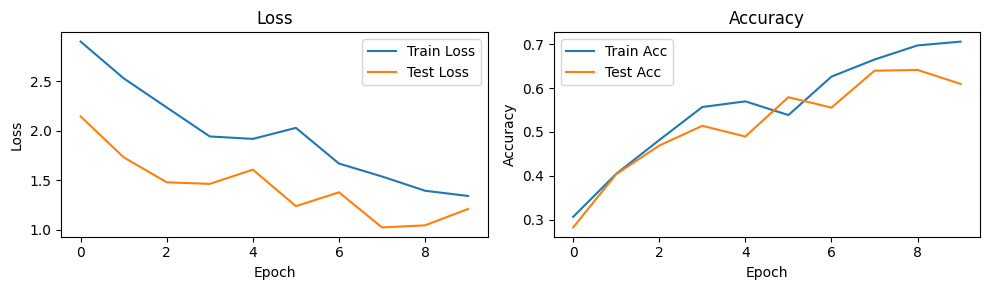

Final Test Accuracy: 60.97%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['test_loss'], label='Test Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss'); ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['test_acc'], label='Test Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy'); ax2.legend()

plt.tight_layout()
plt.show()

print(f'Final Test Accuracy: {history["test_acc"][-1]*100:.2f}%')

### Observation
Training accuracy climbs steadily while test accuracy plateaus around 60%, indicating overfitting on the limited training data. The auxiliary classifiers help gradients flow through the deep 22-layer network, but limited data and only 10 epochs cap generalization. Stronger augmentation or pretrained weights from a larger dataset would close the gap.

## Per-Class Accuracy

In [ ]:
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        for label, pred in zip(labels, preds):
            class_total[label.item()] += 1
            if label == pred:
                class_correct[label.item()] += 1

per_class = pd.DataFrame({
    'Class': class_names,
    'Correct': class_correct,
    'Total': class_total,
    'Accuracy': [c/t for c, t in zip(class_correct, class_total)]
})
display(per_class)

,Class,Correct,Total,Accuracy
0,airplane,317,457,0.693654
1,bird,307,471,0.651805
2,car,352,443,0.794582
3,cat,189,438,0.431507
4,deer,399,459,0.869281
5,dog,73,453,0.161148
6,horse,310,471,0.658174
7,monkey,164,430,0.381395
8,ship,410,484,0.847107
9,truck,253,444,0.569820


### Observation
Per-class accuracy varies widely — from 16% on dog to 87% on deer. Some classes (dog, monkey, cat) are clearly underfit by the from-scratch model, while others (deer, ship, car) reach much higher accuracy. Performance depends on each class's visual distinctiveness and how it landed in the random train/test split.

## Visualize Predictions

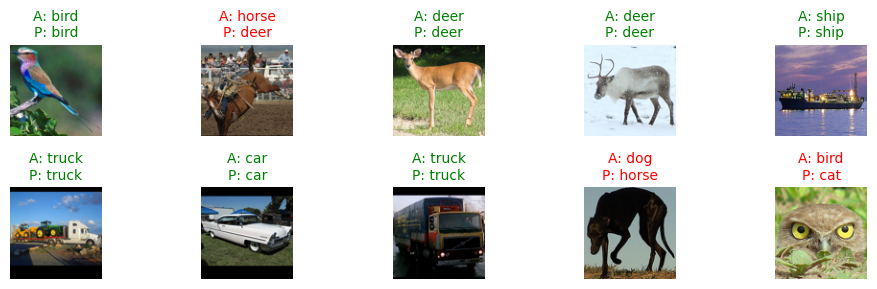

In [ ]:
model.eval()
torch.manual_seed(42)

images, labels = next(iter(test_loader))
images_d = images[:10].to(device)
with torch.no_grad():
    preds = model(images_d).argmax(1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]).permute(1, 2, 0))
    actual = class_names[labels[i]]
    predicted = class_names[preds[i]]
    color = 'green' if labels[i] == preds[i] else 'red'
    ax.set_title(f'A: {actual}\nP: {predicted}', color=color, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Visualize the 4 Branches of an Inception Block
The four branches process the same input at different scales (1x1, 3x3, 5x5, pool). We visualize the average activation of each branch on a sample image.

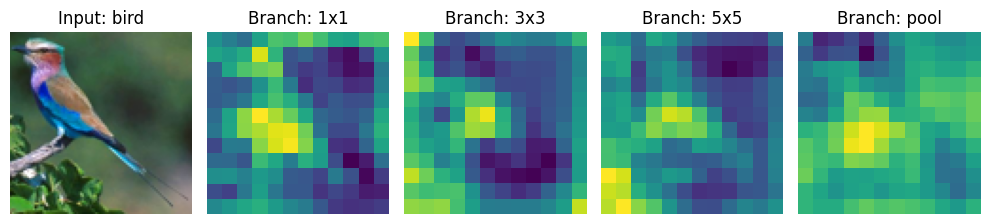

In [ ]:
model.eval()

images, labels = next(iter(test_loader))
img = images[0:1].to(device)

# Forward up to inception3a, then capture each branch of inception3b separately
with torch.no_grad():
    x = model.stem(img)
    x = model.inception3a(x)
    b1 = model.inception3b.branch1(x)
    b2 = model.inception3b.branch2(x)
    b3 = model.inception3b.branch3(x)
    b4 = model.inception3b.branch4(x)

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
axes[0].imshow(denormalize(images[0]).permute(1, 2, 0))
axes[0].set_title(f'Input: {class_names[labels[0]]}'); axes[0].axis('off')
for i, (b, name) in enumerate(zip([b1, b2, b3, b4], ['1x1', '3x3', '5x5', 'pool'])):
    axes[i+1].imshow(b.mean(1).squeeze().cpu(), cmap='viridis')
    axes[i+1].set_title(f'Branch: {name}')
    axes[i+1].axis('off')
plt.tight_layout()
plt.show()

### Observation
Each branch responds to different patterns in the same input. The 1x1 branch reacts to local colour and texture, the 3x3 and 5x5 branches pick up progressively larger structures, and the pool branch captures a smoother summary. Concatenating these gives the network a built-in multi-scale view of the image.

## Pretrained GoogLeNet
Our from-scratch model overfits because STL-10 is small. Let's compare against a GoogLeNet pretrained on ImageNet and fine-tune only the final classifier for our 10 classes.

### Load Pretrained Model

In [ ]:
# Load GoogLeNet pretrained on ImageNet
pretrained_model = torchvision.models.googlenet(weights='IMAGENET1K_V1')

# Disable auxiliary outputs for simpler fine-tuning
pretrained_model.aux_logits = False

# Replace the final classifier layer for 10 classes
pretrained_model.fc = nn.Linear(1024, 10)
pretrained_model = pretrained_model.to(device)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 132MB/s]


In [ ]:
# Freeze all layers; train only the new classifier
for param in pretrained_model.parameters():
    param.requires_grad = False
for param in pretrained_model.fc.parameters():
    param.requires_grad = True

### Prepare Data for Pretrained Model
The pretrained model expects 224x224 inputs with ImageNet normalization, so we re-create the dataloaders accordingly.

In [ ]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

pt_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_dataset_pt = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=pt_transform)
test_dataset_pt = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=pt_transform)

train_loader_pt = DataLoader(train_dataset_pt, batch_size=64, shuffle=True, num_workers=2)
test_loader_pt = DataLoader(test_dataset_pt, batch_size=64, shuffle=False, num_workers=2)

### Train the Pretrained Model

In [ ]:
num_epochs_pt = 5
pt_criterion = nn.CrossEntropyLoss()
pt_optimizer = optim.SGD(pretrained_model.fc.parameters(), lr=0.001, momentum=0.9)

pt_history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs_pt):
    # Training
    pretrained_model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader_pt:
        images, labels = images.to(device), labels.to(device)
        # Single output since aux_logits=False
        out = pretrained_model(images)
        loss = pt_criterion(out, labels)

        pt_optimizer.zero_grad()
        loss.backward()
        pt_optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += images.size(0)
    train_loss, train_acc = running_loss / total, correct / total

    # Evaluation
    test_loss, test_acc = evaluate(pretrained_model, test_loader_pt, pt_criterion, device)

    pt_history['train_loss'].append(train_loss)
    pt_history['train_acc'].append(train_acc)
    pt_history['test_loss'].append(test_loss)
    pt_history['test_acc'].append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs_pt} | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}')

Epoch 1/5 | Train Loss: 1.8615 | Train Acc: 0.5518 | Test Loss: 1.3281 | Test Acc: 0.8972
Epoch 2/5 | Train Loss: 1.0739 | Train Acc: 0.8956 | Test Loss: 0.8453 | Test Acc: 0.9196
Epoch 3/5 | Train Loss: 0.7432 | Train Acc: 0.9138 | Test Loss: 0.6200 | Test Acc: 0.9265
Epoch 4/5 | Train Loss: 0.5826 | Train Acc: 0.9188 | Test Loss: 0.5017 | Test Acc: 0.9309
Epoch 5/5 | Train Loss: 0.4949 | Train Acc: 0.9228 | Test Loss: 0.4419 | Test Acc: 0.9317


### Visualize Predictions (Pretrained Model)

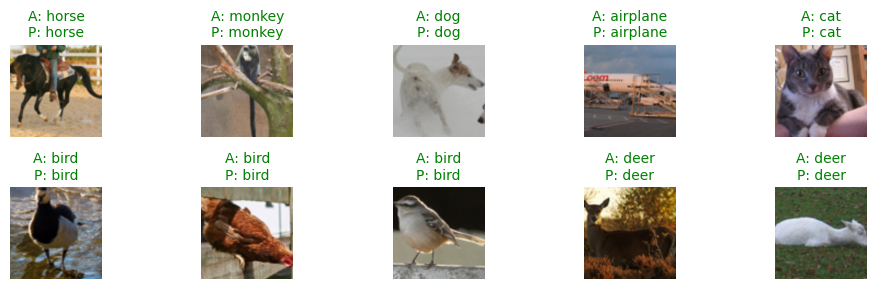

In [ ]:
pretrained_model.eval()

images, labels = next(iter(test_loader_pt))
images_d = images[:10].to(device)
with torch.no_grad():
    preds = pretrained_model(images_d).argmax(1).cpu()

# Denormalize using ImageNet stats
def denormalize_imagenet(img):
    m = torch.tensor(imagenet_mean).view(3, 1, 1)
    s = torch.tensor(imagenet_std).view(3, 1, 1)
    return (img * s + m).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize_imagenet(images[i]).permute(1, 2, 0))
    actual = class_names[labels[i]]
    predicted = class_names[preds[i]]
    color = 'green' if labels[i] == preds[i] else 'red'
    ax.set_title(f'A: {actual}\nP: {predicted}', color=color, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Comparison: From-Scratch vs Pretrained

In [ ]:
comparison = pd.DataFrame({
    'Approach': [f'From Scratch ({num_epochs} epochs)', f'Pretrained + Fine-tuned ({num_epochs_pt} epochs)'],
    'Train Accuracy': [history['train_acc'][-1], pt_history['train_acc'][-1]],
    'Test Accuracy' : [history['test_acc'][-1],  pt_history['test_acc'][-1]],
})
display(comparison)

,Approach,Train Accuracy,Test Accuracy
0,From Scratch (10 epochs),0.706154,0.60967
1,Pretrained + Fine-tuned (5 epochs),0.922800,0.93175


## Observations
- Training from scratch on a small dataset caps generalization at around 60%. Fine-tuning pretrained ImageNet weights lifts test accuracy above 90% in just 5 epochs.